<a href="https://colab.research.google.com/github/tsakailab/MultivariateAnalysis/blob/main/ipynb/plot_normal_distribution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Normal distribution
======================
$ {\rm N}(x;\mu,\sigma^2) = \dfrac{1}{\sqrt{2\pi}\sigma}\, e^{-\dfrac{(x-\mu)^2}{2\sigma^2}}$

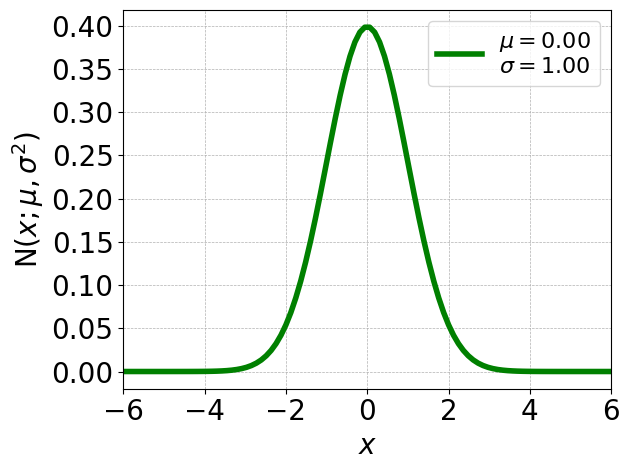

In [ ]:
#@title  { run: "auto" }
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

mu = 0 #@param {type:"slider", min:-5, max:5, step:0.1}
sigma = 1 #@param {type:"slider", min:0.00, max:4, step:0.1}

xrange = 6 #@param {type:"slider", min:0, step:1}

xmin, xmax = -xrange, xrange
x = np.linspace(xmin, xmax, 100)
plt.figure()
ax = plt.axes()

label = '$\\mu=$'+"{:.2f}".format(mu)+'\n$\\sigma=$'+"{:.2f}".format(sigma)
ax.plot(x, stats.norm.pdf(x,mu,sigma), label=label,c='g', lw=4)
plt.xlim(xmin, xmax)
plt.grid(True, ls='--', lw=0.5)
plt.legend(loc="upper right", fontsize=16, frameon=True)
plt.xlabel("$x$", fontsize=20)
plt.ylabel("N$(x;\\mu,\\sigma^2)$", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()

Bivariate normal distribution
=========================
${\rm N}(\boldsymbol{x};\boldsymbol{\mu},\boldsymbol{\varSigma})=\dfrac{1}{\sqrt{(2\pi)^p|\boldsymbol{\varSigma}|}}\,e^{-\frac{1}{2}(\boldsymbol{x}-\boldsymbol{\mu})^\top\boldsymbol{\varSigma}^{-1}(\boldsymbol{x}-\boldsymbol{\mu})}$

$\boldsymbol{x}=\left[\matrix{x_1\\x_2}\right]$, $\boldsymbol{\mu}=\left[\matrix{\mu_1\\\mu_2}\right]$, $\boldsymbol{\varSigma}=\left[\matrix{\sigma_{11}&\sigma_{12}\\ \sigma_{21}&\sigma_{22}}\right]$

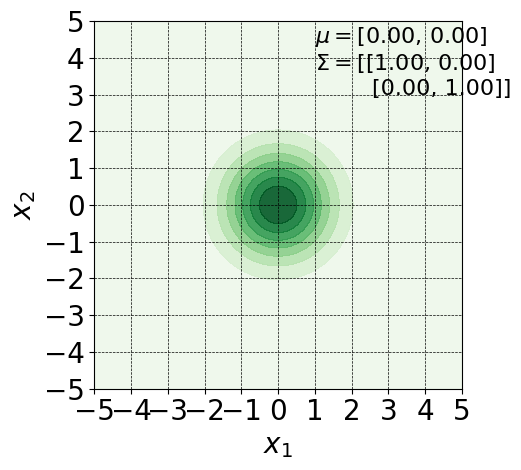

In [ ]:
#@title  { run: "auto" }
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

mu1 = 0 #@param {type:"slider", min:-5, max:5, step:0.1}
mu2 = 0 #@param {type:"slider", min:-5, max:5, step:0.1}
s11 = 1 #@param {type:"slider", min:0.00, max:4, step:0.1}
s12 = -4 #@param {type:"slider", min:-4, max:4, step:0.1}
s22 = 1 #@param {type:"slider", min:0.00, max:4, step:0.1}

if s12*s12 >= s11*s22:
    print("s12*s12 must be smaller than s11*s22")
    s12 = np.sign(s12)*(s11*s22-1e-8)

xmin, xmax = -5,5
x1, x2 = np.mgrid[xmin:xmax:.01, xmin:xmax:.01]
x = np.dstack((x1, x2))

prob = stats.multivariate_normal([mu1, mu2], [[s11, s12], [s12, s22]])

plt.figure()
ax = plt.axes()

ax.contourf(x1, x2, prob.pdf(x), alpha=0.9, cmap=plt.cm.Greens)
label = '$\\mu=$['+"{:.2f}".format(mu1)+', '+"{:.2f}".format(mu2)+']\n$\\Sigma=$[['+"{:.2f}".format(s11)+', '+"{:.2f}".format(s12)+']\n        ['+"{:.2f}".format(s12)+', '+"{:.2f}".format(s22)+']]'
plt.text(1, 3, label, fontsize=16)
plt.xlim(xmin, xmax)
plt.ylim(xmin, xmax)
plt.grid(True, ls='--', lw=0.5, color='k')
plt.xlabel("$x_1$", fontsize=20)
plt.ylabel("$x_2$", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_aspect('equal')
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
plt.tight_layout()

# 多変量正規分布の幾何学的理解：二次形式と固有値分解

分散共分散行列 $\boldsymbol{\varSigma}$ の固有ベクトルは，分布の広がりを表す超楕円体（楕円）の軸（長軸・短軸）の方向を示し，固有値は各軸方向の広がりを表す分散に相当する．
このことを，順を追って説明する。

<br>

## 多変量正規分布の定義と等高線

$p$ 次元確率変数ベクトル $\boldsymbol{x}$ が平均ベクトル $\boldsymbol{\mu}$，分散共分散行列 $\boldsymbol{\varSigma}$ の多変量正規分布に従うとき，その確率密度関数 $P(\boldsymbol{x}; \boldsymbol{\mu}, \boldsymbol{\varSigma})$ は以下の式で定義される．

$$P(\boldsymbol{x}; \boldsymbol{\mu}, \boldsymbol{\varSigma}) = \frac{1}{(2\pi)^{p/2} |\boldsymbol{\varSigma}|^{1/2}} \exp\left( - \frac{1}{2} (\boldsymbol{x} - \boldsymbol{\mu})^\top \boldsymbol{\varSigma}^{-1} (\boldsymbol{x} - \boldsymbol{\mu}) \right)$$

ここで，簡単のために $p=2$（2変数）とし，平均を原点 $\boldsymbol{\mu} = \boldsymbol{0}$ とする．このとき，確率密度関数の形状を決めるのは指数部分である．指数部を定数 $c$ とおくと，密度が一定となる等高線の方程式が得られる．

$$\boldsymbol{x}^\top \boldsymbol{\varSigma}^{-1} \boldsymbol{x} = c \quad (c > 0)$$

この方程式がどのような図形を描くか．

<br>

## 図形の変形と行列による表現

### 標準正規分布：単位行列と円の方程式

最も単純なケースとして，変数が互いに独立で，かつ分散が共に $1$ である場合を考える．このとき，分散共分散行列は単位行列 $\boldsymbol{I}$ となり，その逆行列も $\boldsymbol{I}$ である．$p=2$ では $\boldsymbol{\varSigma}^{-1}=\boldsymbol{I}_2$ から，

$$\boldsymbol{x}^\top \boldsymbol{I}_2 \boldsymbol{x} = \begin{bmatrix} x_1 & x_2 \end{bmatrix} \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \end{bmatrix} = x_1^2 + x_2^2 = c$$

これは原点を中心とする円の方程式である．

特に $c=1$ の単位円は，標準正規分布の変曲点に基づく分布の広がりの目安となる．
以降，ここでは「目安の等高線（reference contour）」と呼ぶことにする．

<br>

### 無相関の正規分布：楕円の方程式

単位円を $x_1$ 方向に $\sigma_1$ 倍，$x_2$ 方向に $\sigma_2$ 倍に引き伸ばすと，$x_1$ と $x_2$ の分散がそれぞれ $\sigma_1$ と $\sigma_2$ の，無相関の正規分布の目安の等高線になる．これは変数を以下のように置き換えることに相当する．

$$x_1 \longmapsto \frac{x_1}{\sigma_1}, \quad x_2 \longmapsto \frac{x_2}{\sigma_2}$$

円の方程式に適用すると，

$$x_1^2 + x_2^2 = 1 \quad\longmapsto\quad \frac{x_1^2}{\sigma_1^2} + \frac{x_2^2}{\sigma_2^2} = 1$$

これは長軸と短軸が座標軸に沿った楕円の方程式である．
もし $\sigma_1>\sigma_2$ の場合は，$x_1$軸が長軸，$x_2$軸が短軸に平行である．

対角行列 $\boldsymbol{D} = \text{diag}(\sigma_1^2, \sigma_2^2)$ を用いると，以下のようにも書ける．

$$\frac{x_1^2}{\sigma_1^2} + \frac{x_2^2}{\sigma_2^2} = \begin{bmatrix} x_1 & x_2 \end{bmatrix} \begin{bmatrix} \frac{1}{\sigma_1^2} & 0 \\ 0 & \frac{1}{\sigma_2^2} \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \end{bmatrix}$$

$$\therefore\quad\boldsymbol{x}^\top \boldsymbol{D}^{-1} \boldsymbol{x} = 1$$

<br>

### 相関のある正規分布：斜めの楕円の方程式

楕円を原点周りに角度 $\theta$ だけ回転させる．回転の変換は，回転行列 $\boldsymbol{R}$ による線形写像である．

$$\boldsymbol{R} = \begin{bmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{bmatrix} = \begin{bmatrix} \boldsymbol{v}^{(1)} & \boldsymbol{v}^{(2)} \end{bmatrix}$$

ここで，$\boldsymbol{v}^{(1)}, \boldsymbol{v}^{(2)}$ は $\boldsymbol{R}$ の列ベクトルであり，互いに直交し，回転後の新しい座標軸（楕円の軸）の方向を表す単位ベクトルである．

逆回転の変換は逆行列 $\boldsymbol{R}$ によって表される．

$$\boldsymbol{R}^{-1} = \frac{1}{\cos\theta\cos\theta+\sin\theta\sin\theta}\begin{bmatrix} \cos\theta & \sin\theta \\ -\sin\theta & \cos\theta \end{bmatrix} = \boldsymbol{R}^\top$$

以下の置き換えを施すと，元の座標系で表した回転後の図形の方程式が得られる．

$$\boldsymbol{x} \longmapsto \boldsymbol{R}^{-1}\boldsymbol{x}$$

楕円の方程式に適用し，相関のある正規分布の目安の等高線の方程式を得る．

$$\boldsymbol{x}^\top \boldsymbol{D}^{-1} \boldsymbol{x}\quad\longmapsto\quad (\boldsymbol{R}^{-1} \boldsymbol{x})^\top \boldsymbol{D}^{-1} (\boldsymbol{R}^{-1} \boldsymbol{x}) =  \boldsymbol{x}^\top (\boldsymbol{R}^{-1})^\top \boldsymbol{D}^{-1}\boldsymbol{R}^{-1}\boldsymbol{x}=\boldsymbol{x}^\top (\boldsymbol{R} \boldsymbol{D}^{-1} \boldsymbol{R}^{-1}) \boldsymbol{x}$$

$$\therefore \boldsymbol{x}^\top \boldsymbol{A} \boldsymbol{x} = 1\qquad (\boldsymbol{A}=\boldsymbol{R} \boldsymbol{D}^{-1} \boldsymbol{R}^{-1})\qquad(1)$$

この方程式が表す回転後の楕円の軸の方向ベクトルは $\boldsymbol{v}^{(1)}$ と $\boldsymbol{v}^{(2)}$ である．

行列 $\boldsymbol{A}$ が $\boldsymbol{R}$ で対角化されていることから，$\boldsymbol{A}$ の固有値は $1/\sigma_1^2$ と $1/\sigma_2^2$（$\boldsymbol{D}^{-1}$ の対角要素），固有ベクトルは $\boldsymbol{v}^{(1)}$ と $\boldsymbol{v}^{(2)}$ であることがわかる．

* 正規分布の目安の等高線となる楕円の方程式を $\boldsymbol{x}^\top \boldsymbol{A} \boldsymbol{x} = 1$ で表し，$\boldsymbol{A}$ を固有値分解すると，**楕円の軸の方向**と，**軸方向の分散の逆数**が求まる．
* 【注意1】原点ではなく $\boldsymbol{\mu}$ が中心の正規分布の場合は，目安の等高線は $(\boldsymbol{x-\boldsymbol{\mu}})^\top \boldsymbol{A} (\boldsymbol{x}-\boldsymbol{\mu}) = 1)$ と表せる．
* 【注意2】楕円の等高線が「目安の等高線」でない場合も，$\boldsymbol{A}$ 固有ベクトルから軸の方向が求まる．しかし，固有値は軸方向の分散の逆数ではない．分散の大小や比率がわかる．

<br>

### 分散共分散行列の固有値分解

方程式(1)が目安の等高線となるような正規分布を考える．目安の等高線 $\boldsymbol{x}^\top \boldsymbol{\varSigma}^{-1} \boldsymbol{x}=1$ が方程式(1)と一致することから，$\boldsymbol{x}$ の恒等式 $\boldsymbol{x}^\top \boldsymbol{\varSigma}^{-1} \boldsymbol{x}=\boldsymbol{x}^\top\boldsymbol{A}\boldsymbol{x}$ が成り立つ．

$$\boldsymbol{\varSigma}^{-1} = \boldsymbol{R} \boldsymbol{D}^{-1} \boldsymbol{R}^{-1}$$

$$\boldsymbol{\varSigma} = (\boldsymbol{R} \boldsymbol{D}^{-1} \boldsymbol{R}^{-1})^{-1} = (\boldsymbol{R}^{-1})^{-1}(\boldsymbol{D}^{-1})^{-1} \boldsymbol{R}^{-1} = \boldsymbol{R} \boldsymbol{D} \boldsymbol{R}^{-1} $$

$$\boldsymbol{\varSigma} \boldsymbol{R} = \boldsymbol{R} \boldsymbol{D} $$

$$\therefore\qquad \boldsymbol{\varSigma} \boldsymbol{v}^{(1)} = \sigma_1^2 \boldsymbol{v}^{(1)},\quad \boldsymbol{\varSigma} \boldsymbol{v}^{(2)} = \sigma_2^2 \boldsymbol{v}^{(2)}$$

この式は，分散共分散行列 $\boldsymbol{\varSigma}$ の固有値分解そのものである．このことから以下の重要な結論が得られる．

* 分散共分散行列 $\boldsymbol{\varSigma}$ の固有ベクトル $\boldsymbol{v}^{(1)}, \boldsymbol{v}^{(2)}$
 （行列 $\boldsymbol{R}$ の各列）は，等高線の楕円の長軸および短軸の方向ベクトルである．
* $\boldsymbol{\varSigma}$ の固有値 $\sigma_1^2, \sigma_2^2$（行列 $\boldsymbol{D}$ の対角要素）は，それぞれの軸方向の分散を表す．

以上の議論は $p\geq 2$ で成立する．一般に，分散共分散行列 $\boldsymbol{\varSigma}$ の固有ベクトルは，分布の広がりを表す超楕円体（楕円）の軸（長軸・短軸）の方向を示し，固有値は各軸方向の広がりを表す分散に相当する．
